tf-idf em tweets #edtwt

In [1]:
%pip install scikit-learn plotly seaborn matplotlib pandas numpy nbformat>=4.2.0 --quiet

zsh:1: 4.2.0 not found
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import ast
import warnings
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

seed = 42

carregamento dos dados

In [3]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, '..', 'entregas', 'p2', 'entrega_2.csv')
json_path = os.path.join(DATA_DIR, '..', 'entregas', 'p2', 'entrega_2_tfidf_features.json')

for p in [csv_path, json_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Arquivo nao encontrado: {p}')

df = pd.read_csv(csv_path)

with open(json_path, 'r') as f:
    tfidf_config = json.load(f)

print(f'Dataset: {df.shape[0]} tweets, {df.shape[1]} colunas')
print('\nconfiguracao do tfidfvectorizer:')
for k, v in tfidf_config.get('vectorizer', {}).items():
    print(f'  {k}: {v}')
print(f'\nFeatures no vocabulario: {len(tfidf_config.get("feature_names", []))}')
print(f'Amostra de features: {tfidf_config.get("feature_names", [])[:15]}')

Dataset: 2353 tweets, 34 colunas

Configuracao do TfidfVectorizer:
  max_df: 0.85
  min_df: 2
  max_features: 1000
  token_pattern: (?u)\b\w\w+\b
  lowercase: False

Features no vocabulario: 1000
Amostra de features: ['10kg', '12h', '14h', '15h', '16', '16h', '20kg', '24h', '2kg', '3kg', '40', '40kg', '43kg', '45kg', '4kg']


reconstrução da matriz densa

In [4]:
def parse_features_tfidf(feature_str):
    if pd.isna(feature_str):
        return {}
    try:
        return ast.literal_eval(feature_str)
    except (ValueError, SyntaxError):
        return {}

nomes_features = tfidf_config.get('feature_names', [])
dicts_tfidf = df['features_tfidf_sklearn'].apply(parse_features_tfidf)

vetores_tfidf = np.zeros((len(df), len(nomes_features)), dtype=np.float32)
for i, d in enumerate(dicts_tfidf):
    for idx_f, feat_name in enumerate(nomes_features):
        vetores_tfidf[i, idx_f] = d.get(feat_name, 0.0)

documentos = df['text'].values

print(f'Vetores TF-IDF: {vetores_tfidf.shape}')
print(f'Dimensao de cada vetor: {vetores_tfidf.shape[1]}')
print(f'Total de documentos validos: {vetores_tfidf.shape[0]}')
print(f'Densidade media: {(vetores_tfidf > 0).mean():.2%}')

Vetores TF-IDF: (2353, 1000)
Dimensao de cada vetor: 1000
Total de documentos validos: 2353
Densidade media: 0.65%


diagnóstico da similaridade de cosseno

In [5]:
sim_raw = cosine_similarity(vetores_tfidf)
upper_raw = sim_raw[np.triu_indices_from(sim_raw, k=1)]

print('=== Similaridade de Cosseno ORIGINAL (sem centralizacao) ===')
print(f'  Media: {upper_raw.mean():.6f}')
print(f'  Desvio padrao: {upper_raw.std():.6f}')
print(f'  Minimo: {upper_raw.min():.4f}  |  Maximo: {upper_raw.max():.4f}')
print(f'  Mediana: {np.median(upper_raw):.6f}')

=== Similaridade de Cosseno ORIGINAL (sem centralizacao) ===
  Media: 0.013920
  Desvio padrao: 0.055119
  Minimo: 0.0000  |  Maximo: 1.0000
  Mediana: 0.000000


In [6]:
vetor_medio_global = vetores_tfidf.mean(axis=0)
vetores_centralizados = vetores_tfidf - vetor_medio_global

sim_cent = cosine_similarity(vetores_centralizados)
upper_cent = sim_cent[np.triu_indices_from(sim_cent, k=1)]

print('=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===')
print(f'  Media: {upper_cent.mean():.6f}')
print(f'  Desvio padrao: {upper_cent.std():.6f}')
print(f'  Minimo: {upper_cent.min():.4f}  |  Maximo: {upper_cent.max():.4f}')
print(f'  Mediana: {np.median(upper_cent):.6f}')

=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===
  Media: -0.000181
  Desvio padrao: 0.059273
  Minimo: -0.2984  |  Maximo: 1.0000
  Mediana: -0.011324


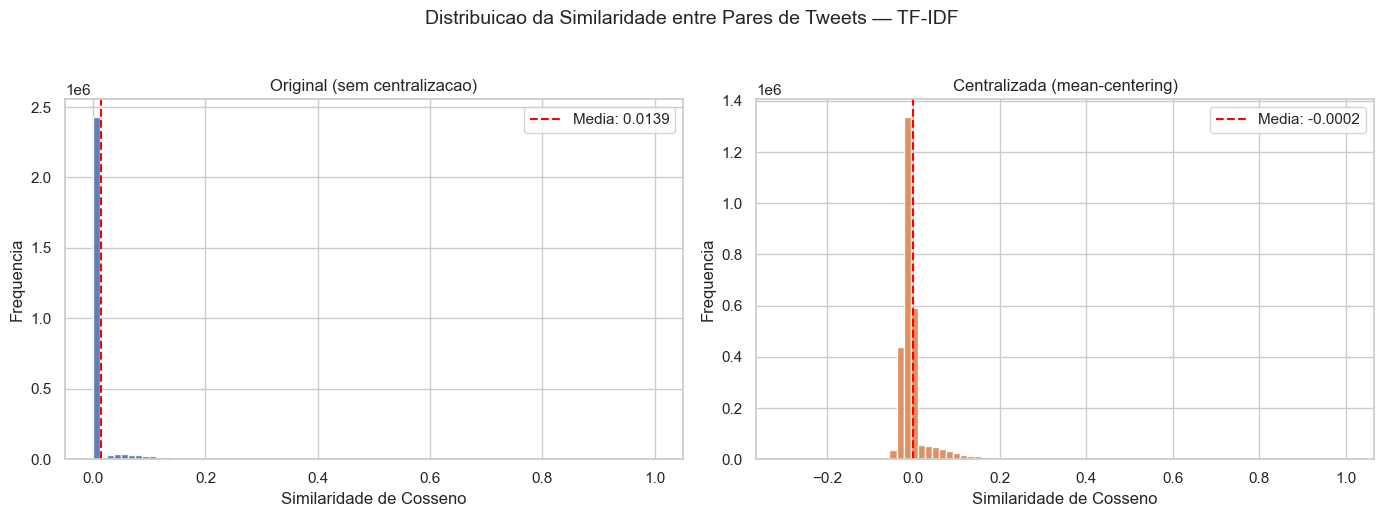

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(upper_raw, bins=80, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].axvline(upper_raw.mean(), color='red', linestyle='--', label=f'Media: {upper_raw.mean():.4f}')
axes[0].set_title('Original (sem centralizacao)', fontsize=12)
axes[0].set_xlabel('Similaridade de Cosseno')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

axes[1].hist(upper_cent, bins=80, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].axvline(upper_cent.mean(), color='red', linestyle='--', label=f'Media: {upper_cent.mean():.4f}')
axes[1].set_title('Centralizada (mean-centering)', fontsize=12)
axes[1].set_xlabel('Similaridade de Cosseno')
axes[1].set_ylabel('Frequencia')
axes[1].legend()

plt.suptitle('Distribuicao da Similaridade entre Pares de Tweets — TF-IDF', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

heatmap de similaridade centralizada (amostra)

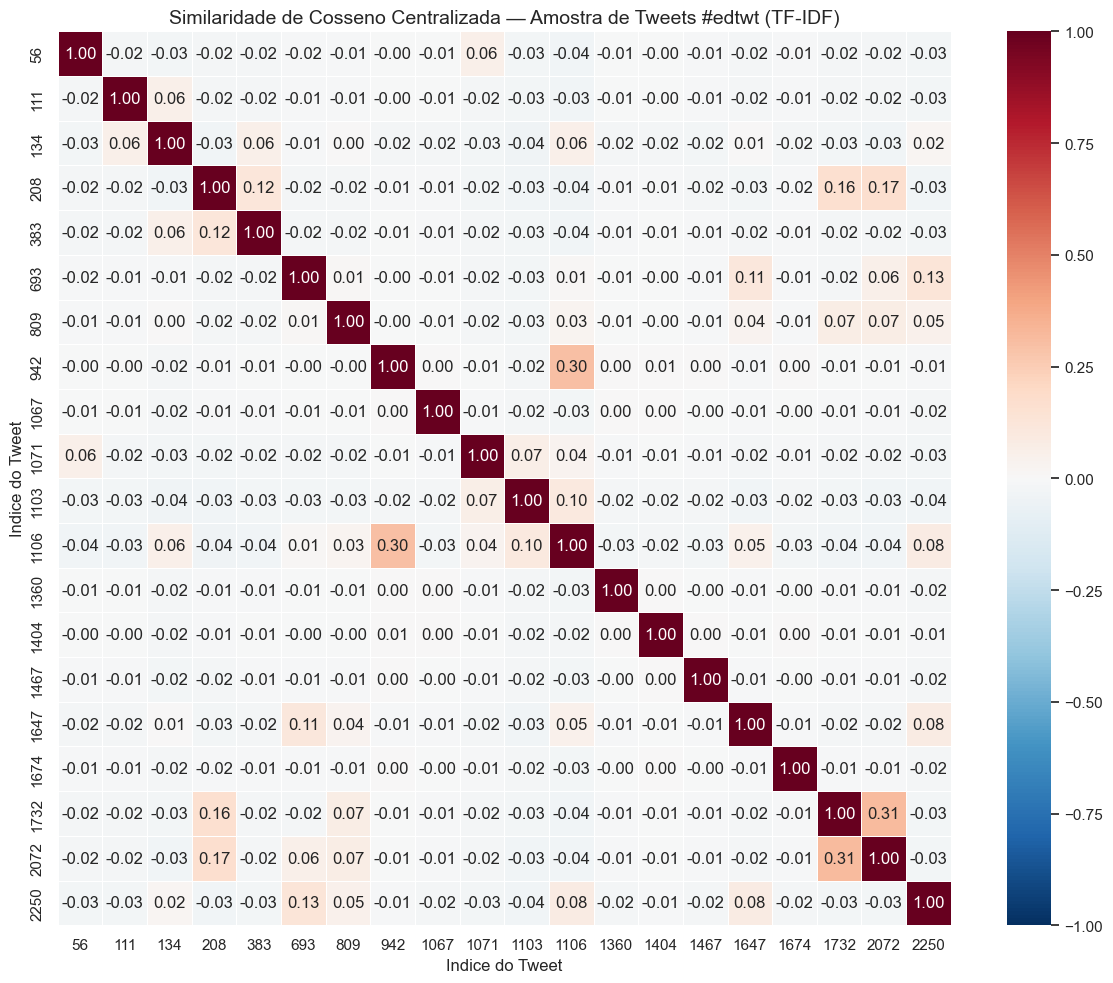

In [8]:
np.random.seed(seed)
n_amostra = min(20, len(documentos))
indices_amostra = np.sort(np.random.choice(len(documentos), size=n_amostra, replace=False))

matriz_amostra = sim_cent[np.ix_(indices_amostra, indices_amostra)]
labels = [str(i) for i in indices_amostra]

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_amostra,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=.5,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1
)
plt.title('Similaridade de Cosseno Centralizada — Amostra de Tweets #edtwt (TF-IDF)', fontsize=14)
plt.xlabel('Indice do Tweet', fontsize=12)
plt.ylabel('Indice do Tweet', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
print('tweets da amostra:\n')
for i in indices_amostra:
    texto = documentos[i].replace('\n', ' ')[:90]
    print(f'  [{i}] {texto}{"..." if len(documentos[i]) > 90 else ""}')

Tweets da amostra:

  [56] Uma mulher de 40 anos agindo como adolescente, antes do atestado, no final do plantão a fa...
  [111] 24h de nf, se eu n conseguir isso sou uma inutil #edtwt
  [134] Duas armaguradas, gordas e são viciadas em álcool e eu fiz mentira vira verdade eu não fum...
  [208] preciso perder 5kg logo #bc #shedtwt #edtwt https://t.co/p22rFW53c0
  [383] pessoas que são/já foram acima de 70kg me respondam:  o que fizeram vocês perder peso de f...
  [693] quando vc pede skinny jeans emprestado pra sua namorada de 1,60 50kg e ainda tem que usar ...
  [809] Receitas saudáveis,low carb e sem açucares pra o natal 🌲✨️ Uma #thread para o #edtwt 🧵 htt...
  [942] Omad com copo da felicidade amanhã.. Apoiam?  #edtwt
  [1067] Nós do pony club assumimos hj que somos do #edtwt
  [1071] fiquei com preguiça de fazer comida ontem e trouxe pipoca para almoçar #edtwt
  [1103] Emagreci dms slc acho q comi um verme #edtwt https://t.co/QOksUHG0Ld
  [1106] Não vou comer amanhã no senai pra com

busca por similaridade (termos do vocabulário)

In [10]:
def buscar_tweets_tfidf(termo, nomes_features, vetores_cent, vetor_medio_global, documentos, num_resultados=10):
    if termo not in nomes_features:
        print(f'Termo "{termo}" nao encontrado no vocabulario TF-IDF.')
        print(f'Termos similares: {[f for f in nomes_features if termo[:3] in f][:10]}')
        return pd.DataFrame({'Tweet': [], 'Similaridade': []})

    idx_termo = list(nomes_features).index(termo)
    vetor_busca = np.zeros(len(nomes_features))
    vetor_busca[idx_termo] = 1.0
    vetor_busca_cent = vetor_busca - vetor_medio_global

    similaridades = cosine_similarity(vetor_busca_cent.reshape(1, -1), vetores_cent)[0]
    indices_ranqueados = np.argsort(similaridades)[::-1]

    pd.set_option('display.max_colwidth', None)
    resultados = pd.DataFrame({
        'Tweet': [documentos[i].replace('\n', ' ')[:1000] for i in indices_ranqueados[:num_resultados]],
        'Similaridade': similaridades[indices_ranqueados[:num_resultados]]
    })
    return resultados

termo = input('Digite o termo de busca: ')
resultados = buscar_tweets_tfidf(termo, nomes_features, vetores_centralizados, vetor_medio_global, documentos)
if not resultados.empty:
    print(f'\nTop {len(resultados)} resultados para "{termo}":')
resultados

Termo "comid" nao encontrado no vocabulario TF-IDF.
Termos similares: ['acompanh', 'com', 'comec', 'coment', 'comentári', 'comidinh', 'comig', 'compactu', 'compar', 'compartilh']


,Tweet,Similaridade


agrupamento (clustering) com kmeans

In [11]:
num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, random_state=seed, n_init=10)
kmeans.fit(vetores_centralizados)

df_cluster = pd.DataFrame({'Tweet': documentos, 'Cluster': kmeans.labels_})

print(f'Agrupamento com {num_clusters} clusters:\n')
for c in range(num_clusters):
    cluster = df_cluster[df_cluster['Cluster'] == c]
    print(f'  Cluster {c} ({len(cluster)} tweets):')
    for s in cluster['Tweet'].head(3):
        print(f'    - {s.replace(chr(10), " ")[:100]}')
    print()

print('top termos discriminativos por cluster:')
for c in range(num_clusters):
    mascara = kmeans.labels_ == c
    centroide = vetores_tfidf[mascara].mean(axis=0)
    centroide_outros = vetores_tfidf[~mascara].mean(axis=0)
    diff = centroide - centroide_outros
    top_indices = np.argsort(diff)[-10:][::-1]
    print(f'  Cluster {c}: {", ".join(nomes_features[i] for i in top_indices)}')
    print()

Agrupamento com 3 clusters:

  Cluster 0 (260 tweets):
    - quando eu sinto vontade de comer doce, como um pouco daquela pasta de dente tandy la  #edtwt
    - ︶ ⏝ ︶ ୨୧ ︶ ⏝ ︶ |            COMIDAS  DE  HOJE.  |            Peso  atual  ::  52kls  . |            
    - @inniekitsune vão expor vc falando q comeu 1 fatia de pão o dia todo #edtwt

  Cluster 1 (107 tweets):
    - decidi não almoçar hoje para beber clericot está mt calor #edtwt
    - preciso perder 5kg logo #bc #shedtwt #edtwt https://t.co/p22rFW53c0
    - decidi não almoçar hoje para beber clericot está mt calor #edtwt

  Cluster 2 (1986 tweets):
    - Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎ ．☆．。．:*･ﾟ  Gente eu esqueci de tirar foto do almoço, mas foi arroz 
    - em quanto tempo vocês tiveram resultados notáveis na academia ?  #edtwt #gymtwt #gymgirl
    - A geladeira do edtwt que mora sozinha  #edtwt #nofood  #diet #zerosugar https://t.co/SRvInSbGuj

Top termos discriminativos por cluster:
  Cluster 0: com, dias, pizz, niv, eh, ho

visualização 2d com pca e t-sne

In [12]:
pca_2d = PCA(n_components=2, random_state=seed)
vetores_pca = pca_2d.fit_transform(vetores_centralizados)

var_exp = pca_2d.explained_variance_ratio_
print(f'Variancia explicada: PC1={var_exp[0]:.2%}, PC2={var_exp[1]:.2%}')
print(f'Variancia total explicada (2 PCs): {var_exp.sum():.2%}')

plot_df_pca = pd.DataFrame({
    'PCA 1': vetores_pca[:, 0],
    'PCA 2': vetores_pca[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_pca = px.scatter(
    plot_df_pca, x='PCA 1', y='PCA 2', color='Cluster',
    title=f'PCA 2D: Clusters de Tweets #edtwt ({num_clusters} clusters) — TF-IDF',
    hover_data={'PCA 1': ':.2f', 'PCA 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_pca.update_traces(marker=dict(size=4, opacity=0.7))
fig_pca.show()

Variancia explicada: PC1=1.50%, PC2=1.46%
Variancia total explicada (2 PCs): 2.96%


In [13]:
perplexity = min(30, len(documentos) // 5)
tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity, max_iter=1000)
vetores_tsne = tsne.fit_transform(vetores_centralizados)

plot_df_tsne = pd.DataFrame({
    't-SNE 1': vetores_tsne[:, 0],
    't-SNE 2': vetores_tsne[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_tsne = px.scatter(
    plot_df_tsne, x='t-SNE 1', y='t-SNE 2', color='Cluster',
    title=f't-SNE: Clusters de Tweets #edtwt ({num_clusters} clusters) — TF-IDF',
    hover_data={'t-SNE 1': ':.2f', 't-SNE 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_tsne.update_traces(marker=dict(size=4, opacity=0.7))
fig_tsne.show()

comparação: tf-idf vs. bow

BoW (centralizado):    media=0.0033, std=0.0982
TF-IDF (centralizado): media=-0.0039, std=0.0667
Correlacao entre matrizes: 0.8878


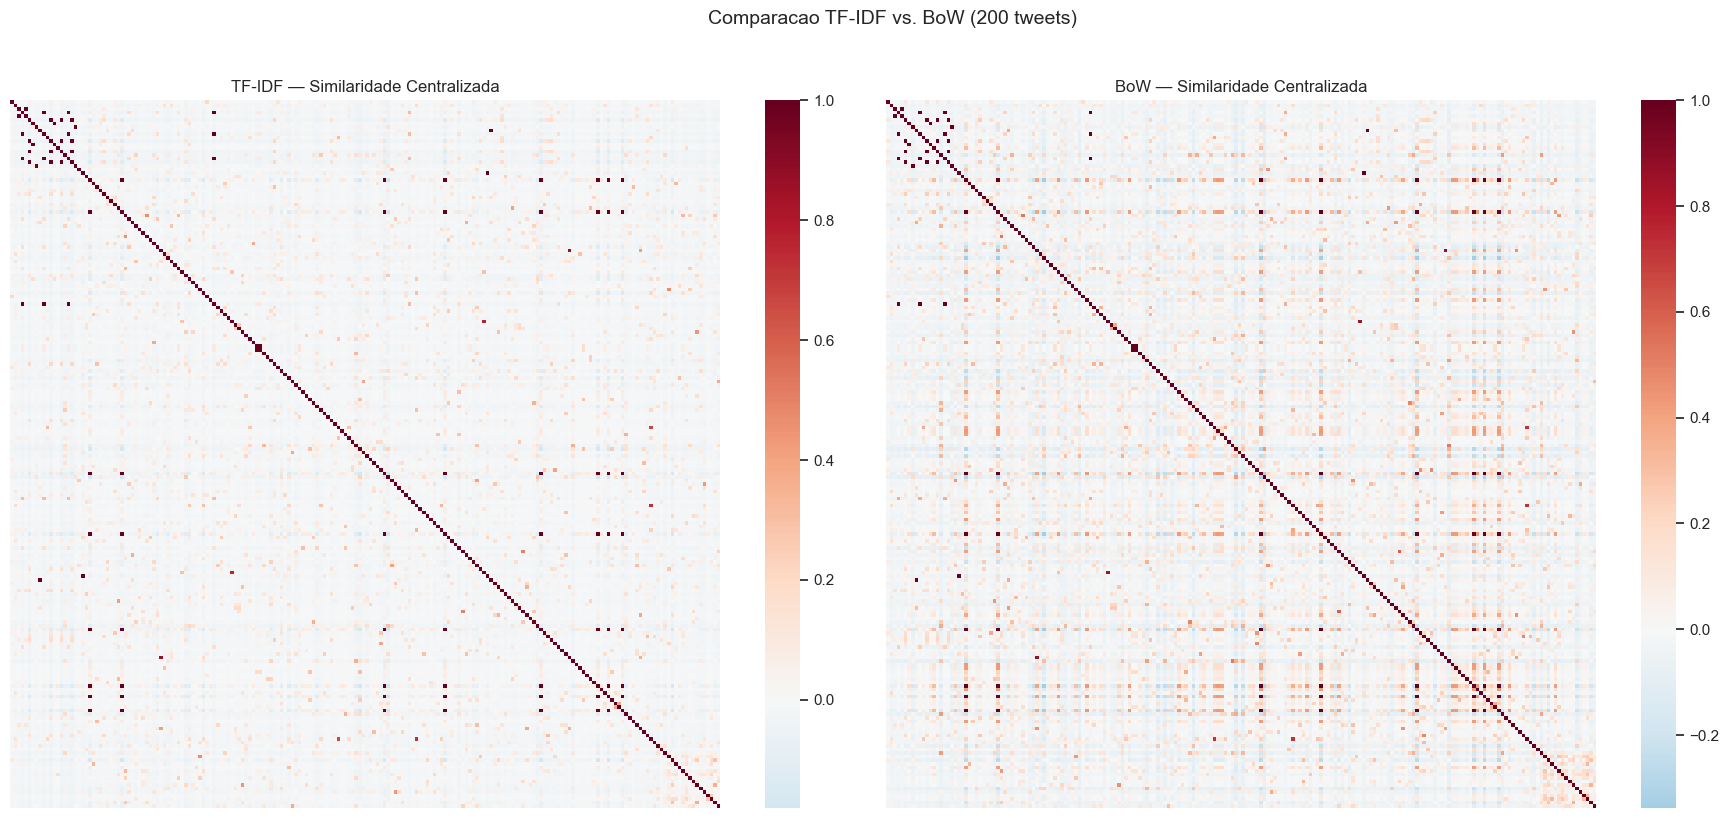

In [14]:
textos_normalizados = df['normalizacao_re'].fillna('').values

vetorizador_bow = CountVectorizer(
    lowercase=False,
    max_df=0.85,
    min_df=2,
    max_features=1000,
    token_pattern=r"(?u)\b\w\w+\b",
)
matriz_bow = vetorizador_bow.fit_transform(textos_normalizados)
vetores_bow = matriz_bow.toarray().astype(np.float32)

np.random.seed(seed)
n_comp = min(200, len(vetores_bow))
idx_comp = np.sort(np.random.choice(len(vetores_bow), size=n_comp, replace=False))

bow_sample = vetores_bow[idx_comp]
tfidf_sample = vetores_tfidf[idx_comp]

bow_sample_cent = bow_sample - bow_sample.mean(axis=0)
tfidf_sample_cent = tfidf_sample - tfidf_sample.mean(axis=0)

sim_bow = cosine_similarity(bow_sample_cent)
sim_tfidf = cosine_similarity(tfidf_sample_cent)

bow_upper = sim_bow[np.triu_indices_from(sim_bow, k=1)]
tfidf_upper = sim_tfidf[np.triu_indices_from(sim_tfidf, k=1)]

print(f'BoW (centralizado):    media={bow_upper.mean():.4f}, std={bow_upper.std():.4f}')
print(f'TF-IDF (centralizado): media={tfidf_upper.mean():.4f}, std={tfidf_upper.std():.4f}')
print(f'Correlacao entre matrizes: {np.corrcoef(sim_bow.flatten(), sim_tfidf.flatten())[0,1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(sim_tfidf, annot=False, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title('TF-IDF — Similaridade Centralizada', fontsize=12)
sns.heatmap(sim_bow, annot=False, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title('BoW — Similaridade Centralizada', fontsize=12)
plt.suptitle('Comparacao TF-IDF vs. BoW (200 tweets)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

observações